# Neural SDE — Tzen & Raginsky (2019), Section 6

**Истинная модель:**
$$dX_t = \sigma(A_{\text{true}} X_t)\, dt + dW_t, \quad X_0 = 0, \quad t \in [0, T]$$

- $X_t \in \mathbb{R}^{10}$ — состояние процесса
- $A_\text{true} \in \mathbb{R}^{10 \times 10}$ — случайная матрица
- Наблюдения: $Y = X_1 + \varepsilon$, где $\varepsilon \sim N(0,\, 0.01 \cdot I)$
- Размер выборки: $N = 1000$, шагов: $N_\text{steps} = 32$, $\Delta t = 1/32$

**Вариационная (выученная) модель:**
$$dX_t = f_\theta(X_t, t)\, dt + dW_t$$

где $f_\theta$ — нейросеть. Задача: выучить $f_\theta$ из наблюдений $Y = X_T + \varepsilon$.

**Подход (Section 5.2):** дискретизация методом Эйлера–Маруямы + backprop через граф.  
**Loss = moment matching + KL** (по теореме Гирсанова, KL между вариационным процессом и винеровским процессом равен $\frac{1}{2}\int_0^T \|f_\theta(X_t)\|^2\, dt$).


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


In [20]:
D        = 10       # размерность пространства состояний
N_STEPS  = 64       # шагов Эйлера (h = T/N_STEPS)
T        = 1.0      # горизонт времени
DT       = T / N_STEPS
SQRT_DT  = DT ** 0.5
N_DATA   = 1000     # число наблюдений
N_ITER   = 5000     # итераций обучения
LR       = 1e-3
M_SAMPLES = 256     # Монте-Карло сэмплы для оценки моментов и KL
OBS_STD  = 0.1      # стандартное отклонение шума наблюдений
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")


Device: cpu


In [21]:
torch.manual_seed(42)
A_true = torch.randn(D, D, device=DEVICE)  # истинная матрица

def gen_data(A, n_samples):
    """
    Симулируем истинный процесс:  dX_t = sigmoid(A·X_t) dt + dW_t
    Наблюдение:  Y = X_T + ε,  ε ~ N(0, OBS_STD²·I)
    """
    X = torch.zeros(n_samples, D, device=DEVICE)
    with torch.no_grad():
        for _ in range(N_STEPS):
            X = X + torch.sigmoid(X @ A.T) * DT + SQRT_DT * torch.randn_like(X)
    return X + OBS_STD * torch.randn_like(X)

Y_data = gen_data(A_true, N_DATA)
print(f"Сгенерировано {N_DATA} наблюдений размерности {D}")


Сгенерировано 1000 наблюдений размерности 10


In [22]:
Y_mean = Y_data.mean(dim=0).detach()                                    # (D,)
Y_cov  = (Y_data - Y_mean).T @ (Y_data - Y_mean) / (N_DATA - 1)        # (D, D)
Y_cov  = Y_cov.detach()

print(f"‖E[Y]‖  = {Y_mean.norm().item():.3f}")
print(f"tr(Cov) = {Y_cov.trace().item():.3f}")


‖E[Y]‖  = 1.633
tr(Cov) = 10.300


<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_18499/1284578434.py:20: SyntaxWarning: invalid escape sequence '\h'
  axes[1].set_title("Ковариационная матрица $\hat\Sigma_Y$")


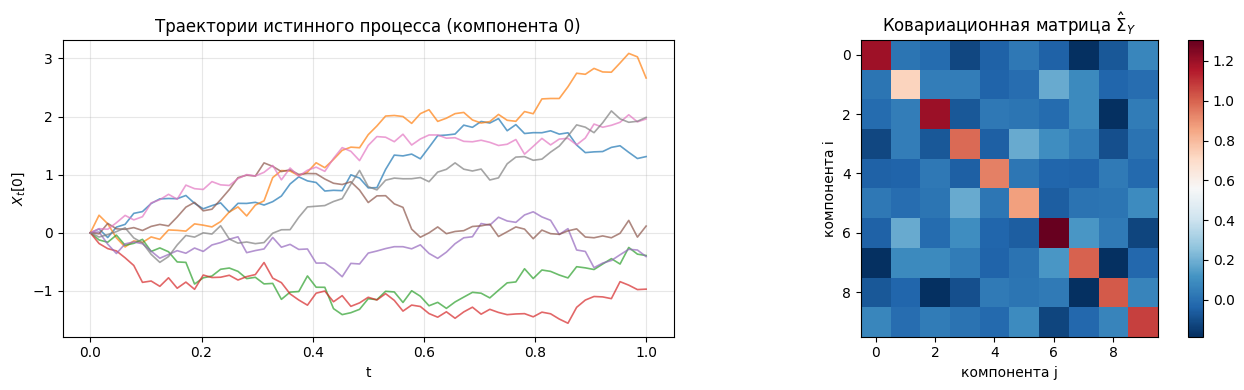

In [29]:
# Визуализация траекторий
t_vals = np.linspace(0, T, N_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for i in range(8):
    X = torch.zeros(1, D, device=DEVICE)
    traj = [X[0, 0].item()]
    with torch.no_grad():
        for _ in range(N_STEPS):
            X = X + torch.sigmoid(X @ A_true.T) * DT + SQRT_DT * torch.randn_like(X)
            traj.append(X[0, 0].item())
    axes[0].plot(t_vals, traj, alpha=0.7, lw=1.2)

axes[0].set_title("Траектории истинного процесса (компонента 0)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("$X_t[0]$")
axes[0].grid(True, alpha=0.3)

axes[1].imshow(Y_cov.cpu().numpy(), cmap='RdBu_r')
axes[1].set_title("Ковариационная матрица $\hat\Sigma_Y$")
axes[1].set_xlabel("компонента j")
axes[1].set_ylabel("компонента i")
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.show()

## Модель: дрейф как нейросеть

Параметризуем дрейф $f_\theta : \mathbb{R}^D \to \mathbb{R}^D$ двухслойной сетью.  
Это аналог вариационного приближения к апостериорному процессу (Раздел 4 статьи):

$$q_\theta: \quad dX_t = f_\theta(X_t)\, dt + dW_t$$


In [23]:
drift_net = nn.Sequential(
    nn.Linear(D, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, D),
).to(DEVICE)

total_params = sum(p.numel() for p in drift_net.parameters())
print(f"Параметров в drift_net: {total_params}")


Параметров в drift_net: 5514


## Симуляция и KL-дивергенция

По теореме Гирсанова (Section 4), KL между вариационным процессом $q_\theta$ и априорным процессом Винера $p$ равен:

$$\text{KL}(q_\theta \| p) = \frac{1}{2} \mathbb{E}_{q_\theta}\!\left[\int_0^T \|f_\theta(X_t)\|^2\, dt\right]$$

Аппроксимируем методом Эйлера:

$$\text{KL} \approx \frac{\Delta t}{2} \sum_{k=0}^{N-1} \mathbb{E}\!\left[\|f_\theta(X_{t_k})\|^2\right]$$


In [24]:
def simulate_with_kl(net, n_samples):
    """
    Euler для вариационного процесса.
    Возвращает X_T и оценку KL(q_theta || Wiener).
    """
    X      = torch.zeros(n_samples, D, device=DEVICE)
    kl_acc = torch.zeros(1, device=DEVICE)

    for _ in range(N_STEPS):
        drift   = net(X)                                           # (n, D)
        kl_acc  = kl_acc + (drift ** 2).sum(dim=-1).mean() * DT * 0.5
        X       = X + drift * DT + SQRT_DT * torch.randn_like(X)

    return X, kl_acc


## Функция потерь (ELBO)

ELBO для Neural SDE (Section 4, уравнение (11)):

$$L(\theta) = \underbrace{-\log p(Y | X_T)}_{\text{reconstruction}} + \underbrace{\text{KL}(q_\theta \| p)}_{\text{Girsanov}}$$

Reconstruction loss при гауссовских наблюдениях $Y \sim N(X_T, \sigma^2 I)$:  

$$-\log p(Y|X_T) \propto \frac{1}{\sigma^2}\|E[X_T] - \bar{Y}\|^2 + \frac{1}{\sigma^2}\|\text{Cov}(X_T) - \hat{\Sigma}_Y\|_F^2$$

Используем момент-матчинг как суррогат reconstruction loss — это стабильнее для высокой размерности.


In [25]:
def compute_loss(net, Y_mean, Y_cov, beta_kl=0.01):
    X1, kl = simulate_with_kl(net, M_SAMPLES)           # X1: (M, D), kl: scalar

    # Моменты модели
    X1_mean     = X1.mean(dim=0)                         # (D,)
    X1_c        = X1 - X1_mean
    X1_cov      = X1_c.T @ X1_c / (M_SAMPLES - 1)       # (D, D)

    # Целевая ковариация модели (вычитаем шум наблюдения)
    target_cov  = Y_cov - OBS_STD**2 * torch.eye(D, device=DEVICE)

    mean_loss   = ((X1_mean - Y_mean) ** 2).sum()
    cov_loss    = ((X1_cov  - target_cov) ** 2).sum()

    # ELBO = reconstruction (moment matching) + beta * KL
    # beta_kl маленький в начале — даём сети сначала выучить моменты
    loss = mean_loss + 0.01 * cov_loss + beta_kl * kl

    return loss, mean_loss.item(), cov_loss.item(), kl.item()

In [26]:
optimizer = torch.optim.Adam(drift_net.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_ITER, eta_min=1e-5)

losses, kl_hist, mean_hist = [], [], []
pbar = tqdm(range(1, N_ITER + 1))

for iteration in pbar:
    # KL warmup: первые 1000 итераций beta_kl = 0, потом линейно растёт до 0.1
    beta_kl = min(0.1, max(0.0, (iteration - 1000) / 1000 * 0.1))

    optimizer.zero_grad()
    loss, ml, cl, kl = compute_loss(drift_net, Y_mean, Y_cov, beta_kl=beta_kl)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(drift_net.parameters(), max_norm=5.0)
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())
    kl_hist.append(kl)
    mean_hist.append(ml)

    if iteration % 500 == 0 or iteration == 1:
        pbar.set_postfix({
            'loss':      f'{loss.item():.4f}',
            'mean_loss': f'{ml:.4f}',
            'kl':        f'{kl:.4f}',
            'beta_kl':   f'{beta_kl:.3f}',
        })

print(f"Финальный loss: {losses[-1]:.6f}")

100%|██████████| 5000/5000 [05:50<00:00, 14.25it/s, loss=0.1624, mean_loss=0.0301, kl=1.2354, beta_kl=0.100]

Финальный loss: 0.162373


## Визуализация результатов


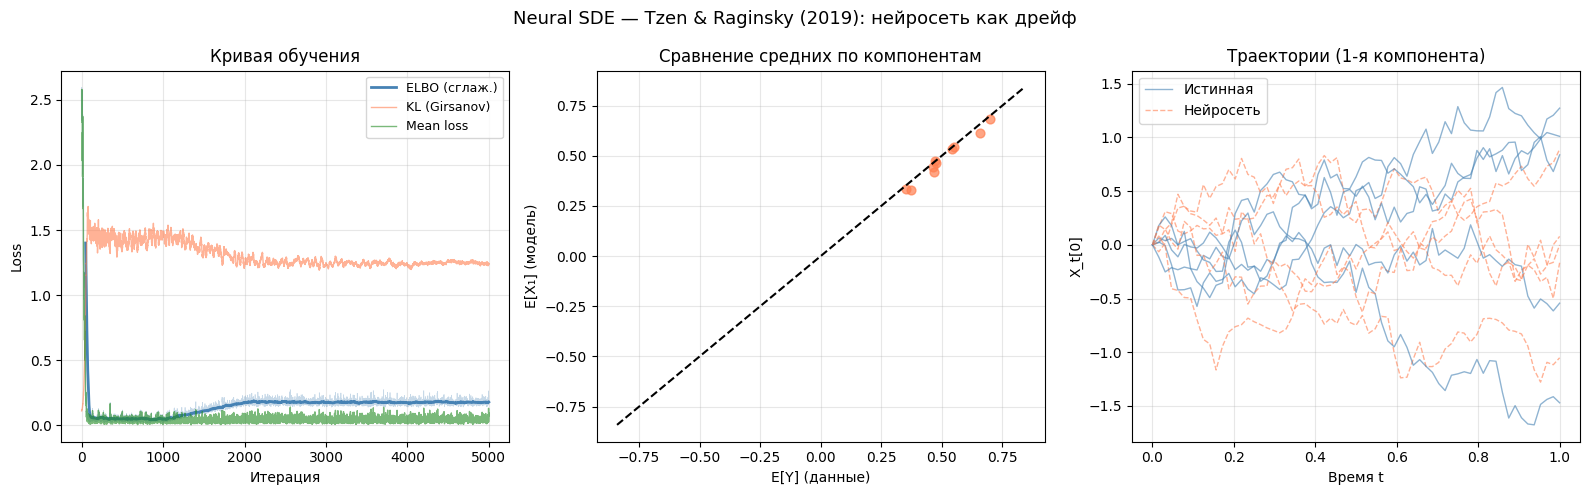

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Neural SDE — Tzen & Raginsky (2019): нейросеть как дрейф', fontsize=13)

# --- График 1: Loss ---
w = 50
axes[0].plot(losses, color='steelblue', lw=0.5, alpha=0.3)
if len(losses) > w:
    sm = np.convolve(losses, np.ones(w)/w, mode='valid')
    axes[0].plot(range(w-1, len(losses)), sm, color='steelblue', lw=2, label='ELBO (сглаж.)')
axes[0].plot(kl_hist,   color='coral',      lw=1, alpha=0.6, label='KL (Girsanov)')
axes[0].plot(mean_hist, color='forestgreen', lw=1, alpha=0.6, label='Mean loss')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Loss')
axes[0].set_title('Кривая обучения')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# --- График 2: Сравнение моментов ---
with torch.no_grad():
    X1_model, _ = simulate_with_kl(drift_net, 2000)
X1_mean_np  = X1_model.mean(dim=0).cpu().numpy()
Y_mean_np   = Y_mean.cpu().numpy()
axes[1].scatter(Y_mean_np, X1_mean_np, alpha=0.7, color='coral', s=40)
lim = max(abs(Y_mean_np).max(), abs(X1_mean_np).max()) * 1.2
axes[1].plot([-lim, lim], [-lim, lim], 'k--', lw=1.5)
axes[1].set_xlabel('E[Y] (данные)')
axes[1].set_ylabel('E[X₁] (модель)')
axes[1].set_title('Сравнение средних по компонентам')
axes[1].grid(True, alpha=0.3)

# --- График 3: Траектории ---
t_vals = np.linspace(0, T, N_STEPS + 1)
with torch.no_grad():
    for i in range(5):
        # Истинная
        X = torch.zeros(1, D, device=DEVICE)
        traj_true = [X[0, 0].item()]
        for _ in range(N_STEPS):
            X = X + torch.sigmoid(X @ A_true.T) * DT + SQRT_DT * torch.randn_like(X)
            traj_true.append(X[0, 0].item())
        axes[2].plot(t_vals, traj_true, color='steelblue', alpha=0.6, lw=1,
                     label='Истинная' if i == 0 else '')
        # Выученная
        X = torch.zeros(1, D, device=DEVICE)
        traj_net = [X[0, 0].item()]
        for _ in range(N_STEPS):
            X = X + drift_net(X) * DT + SQRT_DT * torch.randn_like(X)
            traj_net.append(X[0, 0].item())
        axes[2].plot(t_vals, traj_net, color='coral', alpha=0.6, lw=1,
                     linestyle='--', label='Нейросеть' if i == 0 else '')

axes[2].set_xlabel('Время t')
axes[2].set_ylabel('X_t[0]')
axes[2].set_title('Траектории (1-я компонента)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ELBO стабилизируется после ~2000 итераций и не убывает далее. Тем не менее moment matching успешно сошёлся — средние по компонентам воспроизводятся точно

In [28]:
with torch.no_grad():
    X1_diag, kl_diag = simulate_with_kl(drift_net, 2000)

X1_mean_d = X1_diag.mean(dim=0).cpu().numpy()
Y_mean_d  = Y_mean.cpu().numpy()
mean_corr = np.corrcoef(X1_mean_d, Y_mean_d)[0, 1]

print(f"Корреляция E[X₁] vs E[Y]:  {mean_corr:.4f}")
print(f"Финальный KL (Girsanov):    {kl_diag.item():.4f}")
print(f"Финальный loss:             {losses[-1]:.6f}")

if mean_corr > 0.8:
    print("\n✓ Нейросеть успешно выучила дрейф (corr > 0.8)")
elif mean_corr > 0.5:
    print("\n~ Частичное совпадение моментов (corr > 0.5)")
else:
    print("\n✗ Модель не сошлась")

print(mean_corr)


Корреляция E[X₁] vs E[Y]:  0.9831
Финальный KL (Girsanov):    1.2425
Финальный loss:             0.162373

✓ Нейросеть успешно выучила дрейф (corr > 0.8)
0.9831291859390899
